In [2]:
train_path = "dataset_split/train"
val_path   = "dataset_split/val"

In [14]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [6]:
import os

def clean_ds_store(path):
    for root, dirs, files in os.walk(path):
        for name in files:
            if name == ".DS_Store":
                os.remove(os.path.join(root, name))
        for name in dirs:
            if name == ".DS_Store":
                os.rmdir(os.path.join(root, name))

clean_ds_store("dataset_split")

print("All .DS_Store removed ✅")

All .DS_Store removed ✅


In [7]:
print(os.listdir("dataset_split/train"))

['FreshBanana', 'RottenPomegranate', 'FreshJujube', 'FreshOrange', 'RottenOrange', 'RottenJujube', 'FreshGuava', 'RottenGrape', 'FreshApple', 'RottenBanana', 'RottenGuava', 'FreshStrawberry', 'RottenStrawberry', 'RottenApple', 'FreshGrape', 'FreshPomegranate']


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("dataset_split/train", transform=transform)
val_dataset   = datasets.ImageFolder("dataset_split/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

print(train_dataset.classes)
print(len(train_dataset))

['FreshApple', 'FreshBanana', 'FreshGrape', 'FreshGuava', 'FreshJujube', 'FreshOrange', 'FreshPomegranate', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenGrape', 'RottenGuava', 'RottenJujube', 'RottenOrange', 'RottenPomegranate', 'RottenStrawberry']
2560


In [29]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [30]:
def train_and_evaluate(model, train_loader, val_loader, epochs=5):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": []
    }

    for epoch in range(epochs):

        # ---------- TRAIN ----------
        model.train()
        train_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)

        # ---------- VALIDATION ----------
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():

            for images, labels in tqdm(val_loader, desc="Validation"):

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = nn.CrossEntropyLoss()(outputs, labels)
                val_loss += loss.item()

                preds = outputs.argmax(1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)

        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average="macro")
        rec = recall_score(all_labels, all_preds, average="macro")
        f1 = f1_score(all_labels, all_preds, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(acc)
        history["precision"].append(prec)
        history["recall"].append(rec)
        history["f1"].append(f1)

        print(f"""
Epoch {epoch+1} Results
Train Loss: {train_loss:.4f}
Val Loss: {val_loss:.4f}
Accuracy: {acc*100:.2f}%
Precision: {prec:.3f}
Recall: {rec:.3f}
F1: {f1:.3f}
""")

    return history

In [31]:
num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)

Number of classes: 16


In [32]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [33]:
num_classes = len(train_dataset.classes)

simple_model = SimpleCNN(num_classes)
hist_simple = train_and_evaluate(simple_model, train_loader, val_loader, epochs=5)

Validation: 100%|██████████| 20/20 [00:12<00:00,  1.55it/s]



Epoch 1 Results
Train Loss: 2.0079
Val Loss: 1.2496
Accuracy: 58.44%
Precision: 0.673
Recall: 0.584
F1: 0.579



Validation: 100%|██████████| 20/20 [00:12<00:00,  1.57it/s]



Epoch 2 Results
Train Loss: 1.0459
Val Loss: 0.8267
Accuracy: 72.66%
Precision: 0.754
Recall: 0.727
F1: 0.716



Validation: 100%|██████████| 20/20 [00:12<00:00,  1.57it/s]



Epoch 3 Results
Train Loss: 0.7429
Val Loss: 0.6942
Accuracy: 76.25%
Precision: 0.791
Recall: 0.762
F1: 0.760



Validation: 100%|██████████| 20/20 [00:12<00:00,  1.58it/s]



Epoch 4 Results
Train Loss: 0.5728
Val Loss: 0.6292
Accuracy: 78.91%
Precision: 0.820
Recall: 0.789
F1: 0.783



Validation: 100%|██████████| 20/20 [00:12<00:00,  1.57it/s]


Epoch 5 Results
Train Loss: 0.4550
Val Loss: 0.6249
Accuracy: 78.44%
Precision: 0.807
Recall: 0.784
F1: 0.780



In [34]:
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

hist_resnet = train_and_evaluate(resnet, train_loader, val_loader, epochs=5)

/Users/manideepikauppala/Desktop/majorProject/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/manideepikauppala/Desktop/majorProject/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/manideepikauppala/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:17<00:00, 5.89MB/s]
Validation: 100%|██████████| 20/20 [00:16<00:00,  1.23it/s]



Epoch 1 Results
Train Loss: 0.5606
Val Loss: 0.0790
Accuracy: 98.12%
Precision: 0.982
Recall: 0.981
F1: 0.981



Validation: 100%|██████████| 20/20 [00:15<00:00,  1.25it/s]


...


Epoch 3 Results
Train Loss: 0.0428
Val Loss: 0.1539
Accuracy: 95.47%
Precision: 0.963
Recall: 0.955
F1: 0.950



Validation: 100%|██████████| 20/20 [00:16<00:00,  1.21it/s]



Epoch 4 Results
Train Loss: 0.0518
Val Loss: 0.0607
Accuracy: 98.59%
Precision: 0.987
Recall: 0.986
F1: 0.986



Validation: 100%|██████████| 20/20 [00:15<00:00,  1.25it/s]


Epoch 5 Results
Train Loss: 0.0290
Val Loss: 0.0876
Accuracy: 97.19%
Precision: 0.976
Recall: 0.972
F1: 0.972



In [35]:
mobilenet = models.mobilenet_v3_large(pretrained=True)
mobilenet.classifier[3] = nn.Linear(960, num_classes)

hist_mobile = train_and_evaluate(mobilenet, train_loader, val_loader, epochs=5)

/Users/manideepikauppala/Desktop/majorProject/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/manideepikauppala/Desktop/majorProject/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/5 [Train]:   0%|          | 0/80 [00:02<?, ?it/s]


RuntimeError: linear(): input and weight.T shapes cannot be multiplied (32x1280 and 960x16)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def final_evaluation(model, val_loader, model_name):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100

    print(f"\n===== {model_name} Results =====")
    print(f"Accuracy: {accuracy:.2f}%\n")

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return accuracy

In [37]:
def get_model_size(model):
    total_params = sum(p.numel() for p in model.parameters())
    size_mb = total_params * 4 / (1024**2)
    return total_params, size_mb


===== Simple CNN Results =====
Accuracy: 78.44%

Classification Report:
                   precision    recall  f1-score   support

       FreshApple       0.67      0.70      0.68        40
      FreshBanana       0.88      0.93      0.90        40
       FreshGrape       0.69      0.85      0.76        40
       FreshGuava       1.00      0.93      0.96        40
      FreshJujube       1.00      0.88      0.93        40
      FreshOrange       0.64      0.90      0.75        40
 FreshPomegranate       0.94      0.72      0.82        40
  FreshStrawberry       0.80      0.97      0.88        40
      RottenApple       0.66      0.78      0.71        40
     RottenBanana       0.74      0.97      0.84        40
      RottenGrape       0.86      0.75      0.80        40
      RottenGuava       0.96      0.57      0.72        40
     RottenJujube       0.66      0.93      0.77        40
     RottenOrange       0.85      0.72      0.78        40
RottenPomegranate       0.67      0.50   

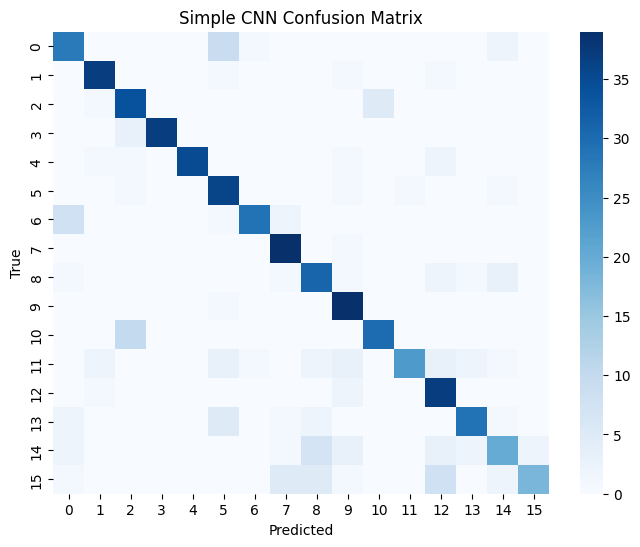

Parameters: 51,482,192
Approx Size: 196.39 MB


In [38]:
acc_cnn = final_evaluation(simple_model, val_loader, "Simple CNN")

params_cnn, size_cnn = get_model_size(simple_model)
print(f"Parameters: {params_cnn:,}")
print(f"Approx Size: {size_cnn:.2f} MB")


===== ResNet50 Results =====
Accuracy: 97.19%

Classification Report:
                   precision    recall  f1-score   support

       FreshApple       1.00      1.00      1.00        40
      FreshBanana       0.98      1.00      0.99        40
       FreshGrape       0.93      1.00      0.96        40
       FreshGuava       1.00      1.00      1.00        40
      FreshJujube       0.78      1.00      0.88        40
      FreshOrange       0.97      0.97      0.97        40
 FreshPomegranate       1.00      1.00      1.00        40
  FreshStrawberry       1.00      1.00      1.00        40
      RottenApple       0.98      1.00      0.99        40
     RottenBanana       1.00      1.00      1.00        40
      RottenGrape       1.00      0.93      0.96        40
      RottenGuava       1.00      0.95      0.97        40
     RottenJujube       0.97      0.75      0.85        40
     RottenOrange       1.00      0.97      0.99        40
RottenPomegranate       1.00      0.97     

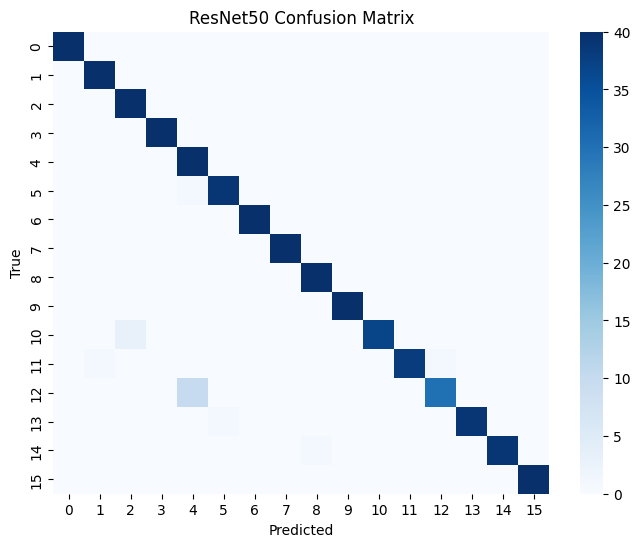

Parameters: 23,540,816
Approx Size: 89.80 MB


In [ ]:
acc_resnet = final_evaluation(resnet, val_loader, "ResNet50")

params_resnet, size_resnet = get_model_size(resnet)
print(f"Parameters: {p arams_resnet:,}")
print(f"Approx Size: {size_resnet:.2f} MB")

In [40]:
acc_mobile = final_evaluation(mobilenet, val_loader, "MobileNetV3")

params_mobile, size_mobile = get_model_size(mobilenet)
print(f"Parameters: {params_mobile:,}")
print(f"Approx Size: {size_mobile:.2f} MB")

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (32x1280 and 960x16)

In [41]:
print("\n===== FINAL COMPARISON =====")
print(f"Simple CNN     → Accuracy: {acc_cnn:.2f}% | Size: {size_cnn:.2f} MB")
print(f"ResNet50       → Accuracy: {acc_resnet:.2f}% | Size: {size_resnet:.2f} MB")


===== FINAL COMPARISON =====
Simple CNN     → Accuracy: 78.44% | Size: 196.39 MB
ResNet50       → Accuracy: 97.19% | Size: 89.80 MB
